# Model Plotting
This notebook plots Figures 5c,d,g and Extended Data 10, and generates the excel file Christian used to generated Figure 5f (and plots a rudimentary version of it). All files are saved to ../figures/

Data is generated by fig5_model_data_generation.ipynb.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import pandas as pd
import matplotlib


plt.rcParams['image.interpolation'] = 'none'
plt.rcParams['image.aspect'] = 'auto'
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['legend.frameon'] = False
plt.rcParams['patch.edgecolor'] = 'none'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.formatter.limits'] = (-3,3)
plt.rcParams['path.simplify'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.style.use("seaborn-paper")

In [2]:
def plot_values(ax, data, valmax, valmin, dashed_line=False, odor=0, alpha=1):
    W=data.W.iloc[0]
    endzone = data.endzone.iloc[0].astype('int')
    T = data['T'].iloc[0]

    
    col = "green" if odor == 0 else "magenta"
    ax.plot(W[:, odor], color=col, ls='--' if dashed_line else '-', alpha=alpha)

    rtime = endzone > 0
    ptime = endzone < 0

    if odor == 0:
        ax.scatter(np.asarray(range(T))[rtime], valmax*(1+.1*(1-dashed_line)) * np.ones(sum(rtime)) , color=col, s=3,  facecolors='none' if dashed_line else col, alpha=alpha)
    else:
        ax.scatter(np.asarray(range(T))[ptime], valmin*(1-.1*(1-dashed_line)) * np.ones(sum(ptime)), color=col, s=3, facecolors='none' if dashed_line else col, alpha=alpha)

def plot_values_by_compartment(ax1, ax2, data, dashed_line=False, alpha=1):
    apcol = '#E66100'
    avcol = '#5D3A9B'
    for i in range(len(data)):
        for odor in range(2):
            m_ap = data.m_ap.iloc[i][:, odor]
            m_av = data.m_av.iloc[i][:, odor]
            ax =ax1 if odor==0 else ax2
            # ax.plot(1, 0, color=apcol, label=r'$w^{\mathrm{ap}}$' if i == 0 else "")
            # ax.plot(1, 0, color=avcol, label=r'$w^{\mathrm{av}}$' if i == 0 else "")
            ax.plot(m_ap, color=apcol, ls='--' if dashed_line else '-', alpha=alpha)
            ax.plot(m_av, color=avcol, ls='--' if dashed_line else '-', alpha=alpha)



## 5c

/var/folders/tt/z91kvz8d6jj096mmy336sdz80000gn/T/ipykernel_76443/3838197027.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


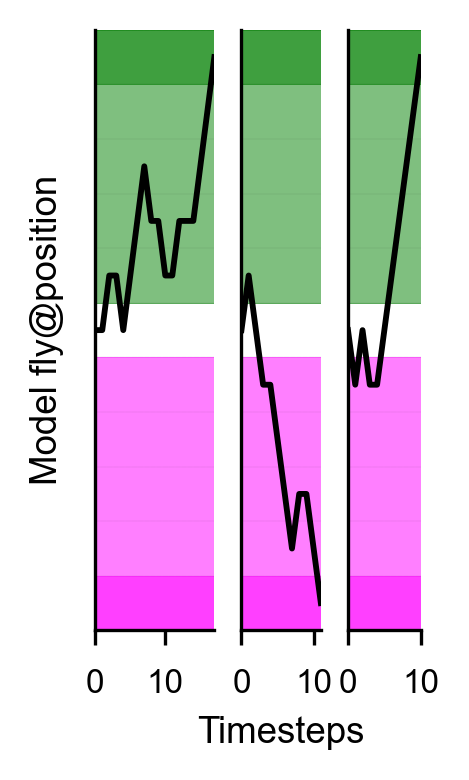

In [3]:
df = pd.read_pickle('../local_data/fig5d.pkl')
row = df[df.mdn_feedback==False].iloc[0]

trials = []
prev_end = 0
endzones = []
for end in np.nonzero(row.endzone)[0]:
    trials.append(list(row.s[prev_end:end+1]))
    endzones.append(row.endzone[end])
    prev_end = end +1

trial_selection = [0,1,4]
f, axs = plt.subplots(1,3, sharex=False, sharey='row', figsize=( 1.4, 2.6), gridspec_kw={'width_ratios': [len(trials[trial_selection[0]]), len(trials[trial_selection[1]]), len(trials[trial_selection[2]])], 'wspace': .3})
next_ax = 0
for i, (trial, end) in enumerate(zip(trials, endzones)):
    if i in trial_selection:
        ax = axs[next_ax]
        next_ax+=1
        if (end == -1 and trial[-1]!=0) or (end == 1 and trial[-1]!=10) :
            trial = [10-t for t in trial] #10-t for t in trial
        y = list(range(len(trial)))
        ax.plot(y, trial, color = 'k')
        ax.set_ylim(-.5, 10.5)
        ax.set_xlim( min(y), max(y))
        ax.axvspan( min(y), max(y), ymin = 0, ymax = 5/11, color = 'magenta', alpha = .5)
        ax.axvspan(min(y), max(y), ymin = 6/11, ymax = 1, color = 'green', alpha = .5)
        ax.axvspan(min(y),max(y),  ymin = 0, ymax = 1/11, color = 'magenta', alpha = .5)
        ax.axvspan(min(y), max(y), ymin = 10/11, ymax = 1, color = 'green', alpha = .5)
        

        for j in range(11):
            ax.axhline(y=j + .5, xmin = 0, xmax = 1, color = 'k', ls = '--',  lw=.039, alpha = .5)
        if i == 0:
            ax.set_ylabel("Model fly@position")
        if i == 1:
            ax.set_xlabel("Timesteps")
        ax.set_yticks([],[])
        


plt.tight_layout()

plt.savefig('../figures/fig5c_example-trials.svg', bbox_inches ='tight')


## 5d

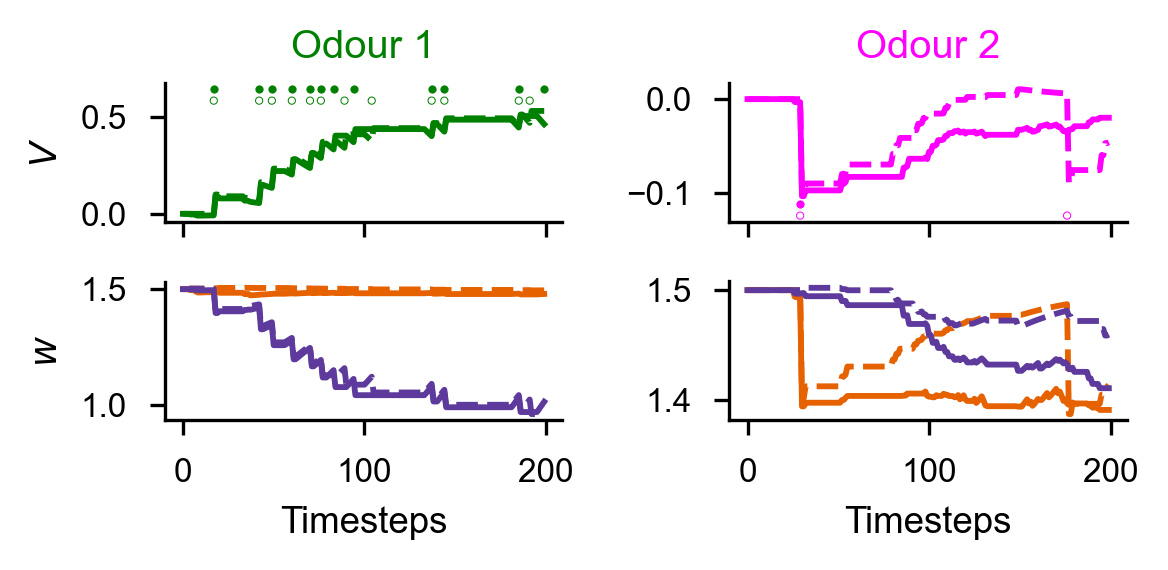

In [4]:
data = pd.read_pickle('../local_data/fig5d.pkl')
f, axs = plt.subplots(2 ,2, sharex=True, sharey=False, figsize=(4,2))
plt.subplots_adjust(wspace=.6)
axs = np.asarray([[axs[0,0], axs[1,0], axs[0,1], axs[1,1]]]).T
valmax = np.max(np.concatenate(list(data.W)))*1.1
valmin = np.min(np.concatenate(list(data.W)))*1.2
for i,(name, subdata) in enumerate(data.groupby('mdn_feedback')):

    if name == True:
        name = 'With MDN feedback'
        i=1
    else:
        name = 'No MDN feedback'
        i = 0
    
    plot_values_by_compartment(axs[1,0], axs[3,0], subdata,1-i)
    plot_values(axs[0,0], subdata, valmax, valmin,1-i, odor=0)
    plot_values(axs[2,0], subdata, valmax, valmin, 1-i,odor = 1)
    if i ==0:
        axs[0,0].set_ylabel( r"$V$")
        axs[0,0].set_title("Odour 1", color = 'green')

        axs[0,0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[2,0].set_title("Odour 2", color='magenta')
        axs[1,0].set_ylabel( r"$w$" )
    axs[1,0].set_xlabel("Timesteps")
    axs[3,0].set_xlabel("Timesteps")

plt.tight_layout()

plt.savefig('../figures/fig5d_model-over-multiple-trials.svg', bbox_inches ='tight')

## 5g

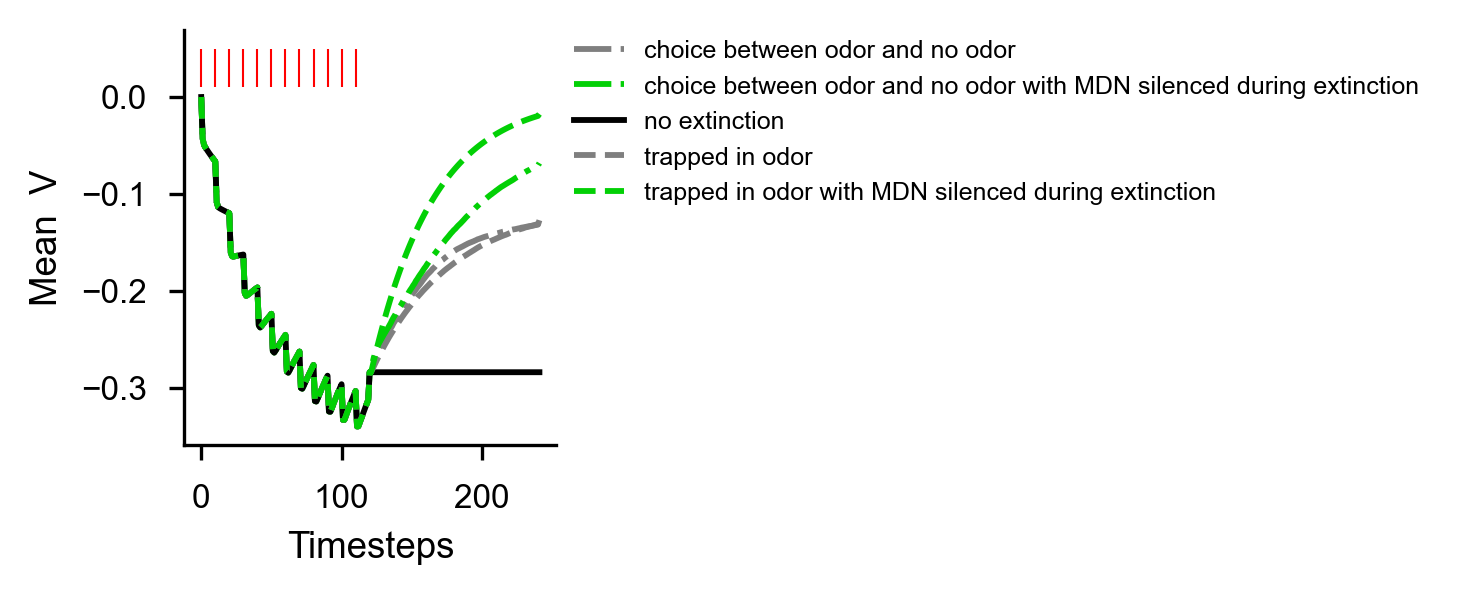

In [5]:
df = pd.read_pickle('../local_data/fig5fg-extinction-data.pkl' )
plt.figure(figsize=(1.6,1.8))
plt.vlines(np.where(df['endzone'].iloc[0]!=0), .01, .05, color='#ff0000ff', lw=.5, ls='-')
for name, data in df.groupby(['trapped_extinction', 'extinction_silenced_mdn']):
    protocol, mdn_extinction_silenced = name
    if protocol=="air":
        color = 'k'
        ls = '-'
    elif mdn_extinction_silenced == True:
        color =  '#02d005ff'
    else:
        color = '#7f7f7fff'
    if protocol == 'odor':
        ls = '--'
    elif protocol == False:
        ls = '-.'

    label = ''
    if name[0] == 'air':
        label = 'no extinction'
    elif name[0] == 'odor':
        label = 'trapped in odor'
        if name[1]:
            label += ' with MDN silenced during extinction'
    elif name[0] == False:
        label = 'choice between odor and no odor'
        if name[1]:
            label += ' with MDN silenced during extinction'
    plt.plot(np.mean(np.vstack(data.W), axis=0), label =label, color = color, ls = ls)
    # plt.fill_between(range(len(data.W.iloc[0])),np.mean(np.vstack(data.W), axis=0)-2*np.std(np.vstack(data.W), axis=0)/np.sqrt(len(data)), np.mean(np.vstack(data.W), axis=0)+2*np.std(np.vstack(data.W), axis=0)/np.sqrt(len(data)),  color = color,   alpha=.3)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=6, borderaxespad=0)
plt.ylabel('Mean  ' + r'V')
plt.xlabel('Timesteps')
plt.savefig('../figures/fig5g_value-extinction.svg', bbox_inches ='tight')
plt.show()

## 5f

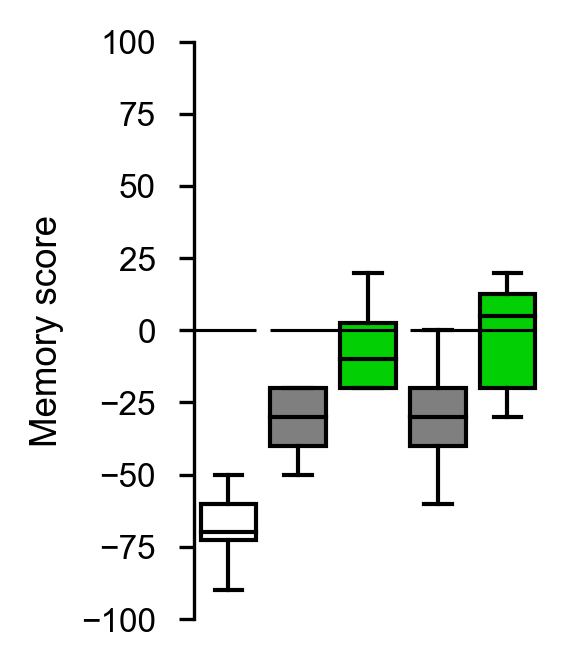

In [6]:
def calculate_pi(x):
    return (np.sum(x==1) - np.sum(x==0))/(np.sum(x==1) + np.sum(x==0))
PI_df = df[['trapped_extinction', 'extinction_silenced_mdn', 'experiment_group', 'choice']].groupby(['trapped_extinction', 'extinction_silenced_mdn', 'experiment_group']).agg(lambda x: calculate_pi(x)*100).reset_index()

protocol_dict = {
    False: 'air vs. odor',
    'air': 'air vs. air',
    'odor': 'odor vs. odor'
}
moonwalker_dict = {
    False: 'yes',
    True: 'no'
}

PI_df['protocol'] = PI_df.trapped_extinction.apply(lambda x: protocol_dict[x])
PI_df['is moonwalker intact?'] = PI_df.extinction_silenced_mdn.apply(lambda x: moonwalker_dict[x])
PI_df.drop(['trapped_extinction', 'extinction_silenced_mdn', 'experiment_group'],axis=1).to_excel('../figures/fig5f-barchart-model-extinction-pi-independent-flies.xlsx')


matplotlib.rcParams.update({'font.size': 9})
plt.figure(figsize=(1.5, 2.5))
bdf = [PI_df[PI_df['trapped_extinction']=='air'].choice, 
 PI_df[(PI_df['trapped_extinction']==False) &(PI_df.extinction_silenced_mdn==False)].choice,
 PI_df[(PI_df['trapped_extinction']==False) &(PI_df.extinction_silenced_mdn==True)].choice,
 PI_df[(PI_df['trapped_extinction']=='odor') &(PI_df.extinction_silenced_mdn==False)].choice,
 PI_df[(PI_df['trapped_extinction']=='odor') &(PI_df.extinction_silenced_mdn==True)].choice,]
            
bplot = plt.boxplot(bdf,
        patch_artist=True, # fill with color
        labels=['Baseline', 'Control', r'MDN1$^A$ silenced', 'Control', r'MDN1$^A$ silenced'],
        widths=.8, whis = (10, 90), showfliers = False)  # will be used to label x-ticks

for patch, color in zip(bplot['boxes'], ['white', '#7f7f7fff', '#02d005ff', '#7f7f7fff', '#02d005ff']):
    patch.set_facecolor(color)
for median in bplot['medians']:
    median.set_color('black')


plt.ylim(-100,100)
plt.ylabel('Memory score')
plt.xticks([],[])
plt.hlines(0,.5,1.4, color='black', linewidth=.75)
plt.hlines(0,1.6,3.4, color='black',linewidth=.75)
plt.hlines(0,3.6,5.4, color='black',linewidth=.75)
plt.gca().spines['bottom'].set_visible(False)



plt.savefig('../figures/fig5f-pre-christian.svg', bbox_inches='tight', dpi=300)

## Extended Data 10a

0
1
2


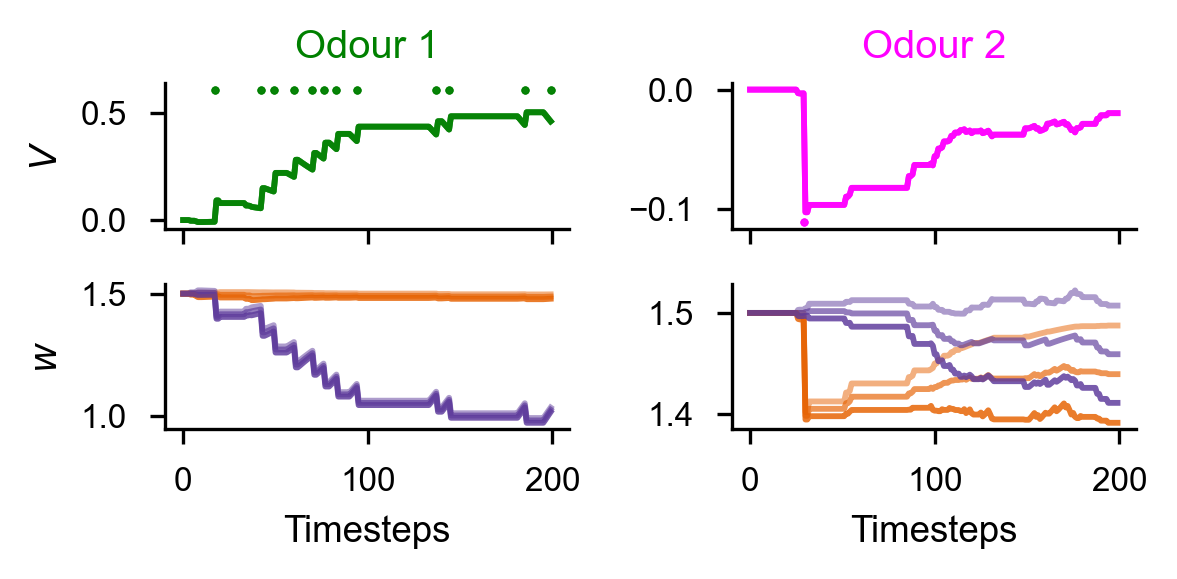

In [7]:

data = pd.read_pickle('../local_data/fig5-supp-mdn-input.pkl')


f, axs = plt.subplots(2 ,2, sharex=True, sharey=False, figsize=(4,2))
plt.subplots_adjust(wspace=.6)
axs = np.asarray([[axs[0,0], axs[1,0], axs[0,1], axs[1,1]]]).T
valmax = np.max(np.concatenate(list(data.W)))*1.1
valmin = np.min(np.concatenate(list(data.W)))*1.2
for i,(name, subdata) in enumerate(data.groupby('mdn_to_dp')):

    if name == 2:
        i=1
    else:
        i = 0
    print(name)
    plot_values_by_compartment(axs[1,0], axs[3,0], subdata, alpha = .5 + name/6)
    plot_values(axs[0,0], subdata, valmax, valmin, odor=0, alpha = .5 + name/6)
    plot_values(axs[2,0], subdata, valmax, valmin, odor = 1, alpha = .5 + name/6)
    if i ==0:
        axs[0,0].set_ylabel(r"$V$")
        axs[0,0].set_title("Odour 1", color = 'green')

        axs[0,0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[2,0].set_title("Odour 2", color='magenta')
        axs[1,0].set_ylabel( r"$w$" )
    axs[1,0].set_xlabel("Timesteps")
    axs[3,0].set_xlabel("Timesteps")

plt.tight_layout()

plt.savefig('../figures/model-supplement_mdn-feedback.svg', bbox_inches ='tight')

## Extended Data 10b

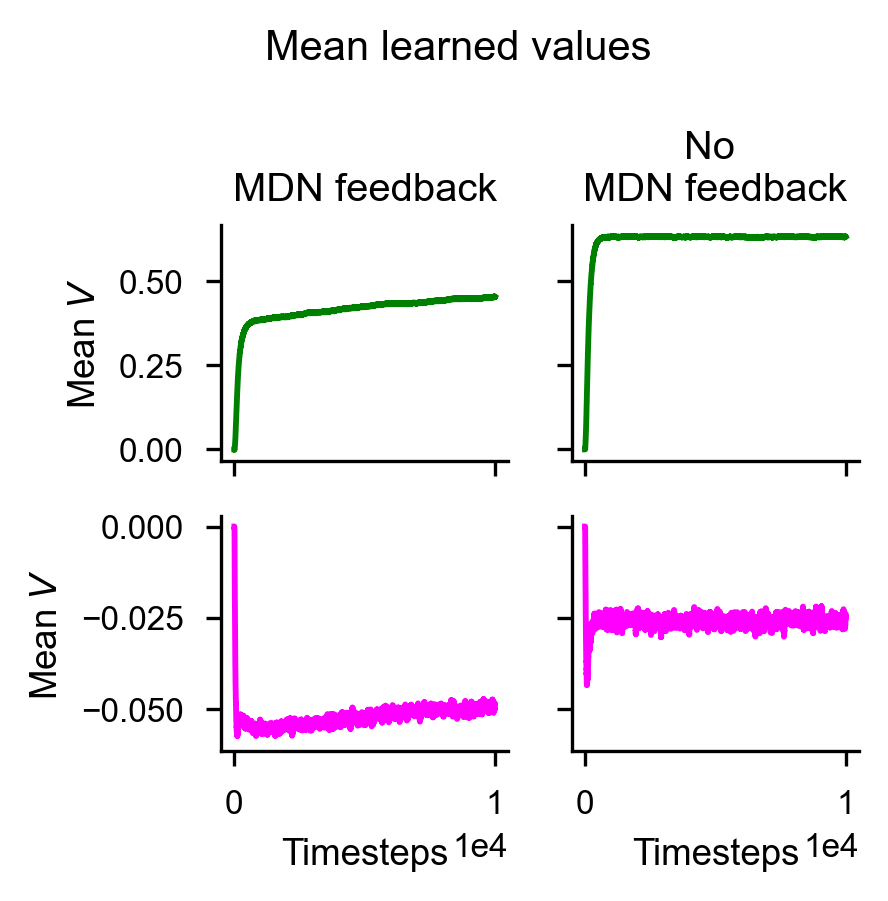

In [8]:

data = pd.read_pickle('../local_data/fig5-bulk-supplement.pkl')


def plot_mean_values(ax, data,  odor):
    W = np.dstack(data['W'])
    error = np.std(W, axis=2)/np.sqrt(len(data)) # standard error of the mean
    W = np.mean(W, axis=2) # mean W

    col = "green" if odor == 0 else "magenta"
    ax.plot(W[:,odor], color = col)
    ax.fill_between(range(len(W[:,odor])), W[:,odor]-error[:,odor], W[:,odor]+error[:,odor], color = col, alpha = .2, linewidth=0.0)

f, axs = plt.subplots(2 ,2, sharex=True, sharey='row', figsize=(3,3))
for i,(name, subdata) in enumerate(data.groupby('mdn_feedback')):
    if name:
        name = 'MDN feedback'
        i=0
    else:
        name = 'No \nMDN feedback'
        i = 1

    plot_mean_values(axs[0,i], subdata,  odor=0)
    plot_mean_values(axs[1,i], subdata,  odor = 1)
    if i ==0:
        axs[0,i].set_ylabel(r'Mean $V$') #+ "\nValue")
        axs[1,i].set_ylabel(r'Mean $V$') #+ "\nValue")
    axs[1 ,i].set_xlabel("Timesteps")
    axs[0,i].set_title(name)
plt.suptitle("Mean learned values", fontsize=10)
plt.tight_layout()


plt.savefig('../figures/model-supplement_mean-learned-values-consistent.svg', bbox_inches ='tight')

## Extended Data 10c

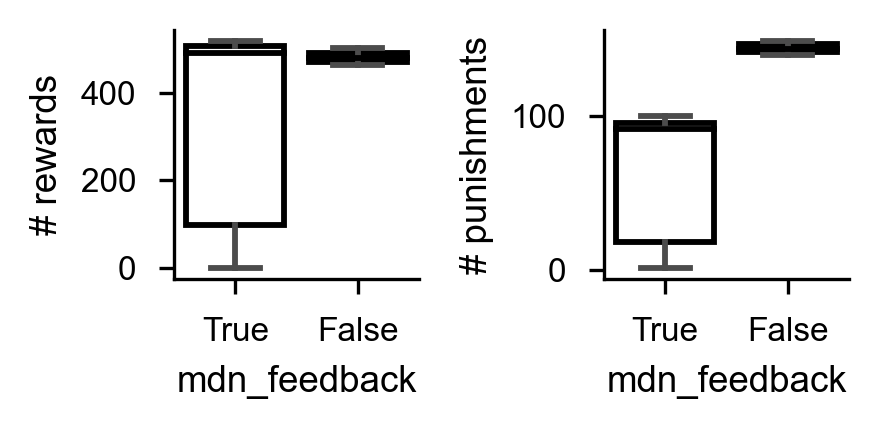

In [9]:
data = pd.read_pickle('../local_data/fig5-bulk-supplement.pkl')
import seaborn as sns
data['n_rewards'] = data.endzone.apply(lambda x: np.sum(x > 0))
data['n_punishments'] = data.endzone.apply(lambda x: np.sum(x < 0))


f, axs = plt.subplots(1 ,2,  figsize=(3,1.5))

sns.boxplot(data = data, x = 'mdn_feedback', y = 'n_rewards', ax=axs[0], order = [True,False], whis=(10,90), showfliers = False, medianprops = {'color': 'k'},palette = ['white', '#5AC53A'],boxprops={'edgecolor': 'k'})
sns.boxplot(data = data, x = 'mdn_feedback', y = 'n_punishments', ax=axs[1], whis=(10,90), showfliers = False, medianprops = {'color': 'k'}, palette = ['white', '#5AC53A'], order = [True,False], boxprops={'edgecolor': 'k'})
axs[0].set_ylabel("# rewards")
axs[1].set_ylabel("# punishments")
plt.tight_layout()


plt.savefig('../figures/model-supplement_r-p-bulk.svg', bbox_inches ='tight')

data['is moonwalker intact?'] = data.mdn_feedback.apply(lambda x: {True: 'Yes', False: 'No'}[x])
data = data.sort_values('is moonwalker intact?').reset_index(drop=True)
data.drop(['W', 'm_ap', 'm_av', 'endzone', 'T', 'seed', 'mdn_feedback'], axis=1).to_excel('../figures/figS10c_n-rewards-n-punishments.xlsx', index=False)